# Couverture Papers With Code (PwC)

Mesurer la couverture entre notre dataset de benchmarks (`merged.parquet`, ~3.7k papiers identifies par **bibkey** ACL) et **Papers With Code**.

PwC a ferme en 2025 : on n'utilise que ses **dumps statiques archives** (`pwc_papers.parquet`, deja telecharge depuis `pwc-archive` sur HuggingFace), pas d'API live.

**Probleme central** : PwC n'indexe pas par bibkey. Ses seules cles exploitables sont `arxiv_id`, `title`, `url_abs`. Le bibkey doit donc etre resolu vers un identifiant que PwC connait.

**Chaine de resolution :**
1. `bibkey` -> `doi` / `anthology id` (via `anthology_enriched.parquet`, construit depuis le package `acl-anthology`, source canonique vivante).
2. `DOI:` / `ACL:` -> **Semantic Scholar** (`/paper/batch`, 500 ids/appel) -> `arxiv_id` + `corpus_paper_id`. Contourne entierement ACL-OCL (fige a 09/2022) pour le pont vers PwC.
3. `arxiv_id` -> match dur contre PwC (zero faux positif).

**Point de vigilance** : on distingue trois causes d'absence, qui ne disent pas la meme chose :
- *pas de lien S2* (`corpus_paper_id` manquant),
- *pas d'arxiv id* (jamais arxive),
- *vrai absent de PwC*.

PwC est arXiv-centre : un taux de couverture faible est **attendu et interpretable** (framing "forgotten benchmark"), pas une faille de pipeline.

In [1]:
import sys
import ast
import time
import logging
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sys.path.insert(0, str(Path().resolve().parent / "src"))
from logging_config import setup_logging

setup_logging()
logger = logging.getLogger("pwc_coverage")

DATA_DIR = Path("../data")
OUT_DIR = DATA_DIR / "pwc_coverage"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PWC_DIR = Path("..")  # pwc_papers.parquet / pwc_datasets.parquet a la racine du repo

## 1. Charger le dataset de benchmarks et resoudre les bibkeys

On part de `merged.parquet` (le set de benchmarks) et on recupere `id` (anthology id) + `doi` via `anthology_enriched.parquet`. On construit ensuite la cle Semantic Scholar : `DOI:<doi>` si disponible, sinon `ACL:<id>`.

In [2]:
benchmarks = pd.read_parquet(DATA_DIR / "taxonomy" / "merged.parquet")
# on ne garde que les benchmarks confirmes (majority vote POSITIVE)
benchmarks = benchmarks[benchmarks["majority_label"] == "POSITIVE"]
anthology = pd.read_parquet(DATA_DIR / "raw" / "anthology_enriched.parquet")

df = benchmarks[["bibkey"]].merge(
    anthology[["bibkey", "id", "doi", "title", "year"]], on="bibkey", how="left"
)


def s2_id(row: pd.Series) -> str | None:
    """Cle Semantic Scholar : DOI prioritaire, sinon anthology id."""
    if isinstance(row["doi"], str) and row["doi"].strip():
        return f"DOI:{row['doi'].strip()}"
    if isinstance(row["id"], str) and row["id"].strip():
        return f"ACL:{row['id'].strip()}"
    return None


df["s2_query_id"] = df.apply(s2_id, axis=1)
df["s2_id_source"] = np.where(df["doi"].notna(), "DOI", "ACL")

logger.info(
    "benchmarks POSITIVE=%d | resolvables=%d | via DOI=%d | via ACL=%d",
    len(df),
    df["s2_query_id"].notna().sum(),
    (df["s2_id_source"] == "DOI").sum(),
    (df["s2_id_source"] == "ACL").sum(),
)
df.head(3)

2026-05-25 14:21:23  INFO      benchmarks POSITIVE=1890 | resolvables=1890 | via DOI=1219 | via ACL=671


,bibkey,id,doi,title,year,s2_query_id,s2_id_source
0,aparovich-etal-2025-belarusianglue,2025.acl-long.25,10.18653/v1/2025.acl-long.25,BelarusianGLUE: Towards a Natural Language Und...,2025,DOI:10.18653/v1/2025.acl-long.25,DOI
1,macko-etal-2025-multisocial,2025.acl-long.36,10.18653/v1/2025.acl-long.36,MultiSocial: Multilingual Benchmark of Machine...,2025,DOI:10.18653/v1/2025.acl-long.36,DOI
2,mangalik-etal-2025-capturing,2025.acl-long.69,10.18653/v1/2025.acl-long.69,Capturing Author Self Beliefs in Social Media ...,2025,DOI:10.18653/v1/2025.acl-long.69,DOI


## 2. Semantic Scholar : `bibkey` -> `arxiv_id` + `corpus_paper_id`

Endpoint `/paper/batch`, 500 ids/appel, champ `externalIds`. Une cle API gratuite (https://www.semanticscholar.org/product/api) accelere et fiabilise le batch ; sans cle ca marche aussi mais avec un rate-limit severe.

Le resultat est mis en cache sur disque (`data/pwc_coverage/s2_resolution.parquet`) : on ne requete que les ids manquants.

In [3]:
S2_API_KEY = ""  # optionnel : colle ta cle ici (ou laisse vide)
S2_BATCH_URL = "https://api.semanticscholar.org/graph/v1/paper/batch"
S2_CACHE = OUT_DIR / "s2_resolution.parquet"


def query_s2_batch(
    ids: list[str], api_key: str = "", batch_size: int = 500, max_retries: int = 4
) -> pd.DataFrame:
    """Resout une liste de cles S2 (DOI:.../ACL:...) en arxiv_id + corpus_paper_id."""
    headers = {"x-api-key": api_key} if api_key else {}
    rows: list[dict] = []
    for start in range(0, len(ids), batch_size):
        chunk = ids[start : start + batch_size]
        for attempt in range(max_retries):
            resp = requests.post(
                S2_BATCH_URL,
                params={"fields": "externalIds,title"},
                json={"ids": chunk},
                headers=headers,
                timeout=60,
            )
            if resp.status_code == 200:
                break
            wait = 2**attempt * 5
            logger.warning(
                "S2 %s (chunk %d) -> retry dans %ds", resp.status_code, start, wait
            )
            time.sleep(wait)
        else:
            raise RuntimeError(f"S2 batch echoue chunk {start}: {resp.status_code}")

        for query_id, rec in zip(chunk, resp.json()):
            ext = (rec or {}).get("externalIds") or {}
            rows.append(
                {
                    "s2_query_id": query_id,
                    "s2_found": rec is not None,
                    "corpus_paper_id": ext.get("CorpusId"),
                    "arxiv_id": ext.get("ArXiv"),
                }
            )
        logger.info("S2 batch %d-%d ok", start, start + len(chunk))
        time.sleep(1.0 if api_key else 3.0)
    return pd.DataFrame(rows)


if S2_CACHE.exists():
    s2 = pd.read_parquet(S2_CACHE)
else:
    s2 = pd.DataFrame(
        columns=["s2_query_id", "s2_found", "corpus_paper_id", "arxiv_id"]
    )

to_query = sorted(set(df["s2_query_id"].dropna()) - set(s2["s2_query_id"]))
logger.info("deja en cache=%d | a requeter=%d", len(s2), len(to_query))

if to_query:
    new = query_s2_batch(to_query, api_key=S2_API_KEY)
    s2 = pd.concat([s2, new], ignore_index=True).drop_duplicates("s2_query_id")
    s2.to_parquet(S2_CACHE, index=False)

df = df.merge(s2, on="s2_query_id", how="left")
df["s2_found"] = df["s2_found"].fillna(False)
df.head(3)

2026-05-25 14:21:23  INFO      deja en cache=3706 | a requeter=0


,bibkey,id,doi,title,year,s2_query_id,s2_id_source,s2_found,corpus_paper_id,arxiv_id
0,aparovich-etal-2025-belarusianglue,2025.acl-long.25,10.18653/v1/2025.acl-long.25,BelarusianGLUE: Towards a Natural Language Und...,2025,DOI:10.18653/v1/2025.acl-long.25,DOI,True,280034711.0,NaN
1,macko-etal-2025-multisocial,2025.acl-long.36,10.18653/v1/2025.acl-long.36,MultiSocial: Multilingual Benchmark of Machine...,2025,DOI:10.18653/v1/2025.acl-long.36,DOI,False,NaN,NaN
2,mangalik-etal-2025-capturing,2025.acl-long.69,10.18653/v1/2025.acl-long.69,Capturing Author Self Beliefs in Social Media ...,2025,DOI:10.18653/v1/2025.acl-long.69,DOI,True,280034719.0,NaN


## 3. Match avec PwC sur `arxiv_id` : papier ET dataset

Deux niveaux de couverture, du plus large au plus precis :

- **papier dans PwC** : l'arxiv id du benchmark apparait dans `pwc_papers.parquet`. Signal "le papier existe sur PwC".
- **dataset dans PwC** : l'arxiv id introduit un *dataset enregistre* dans `pwc_datasets.parquet`. C'est le vrai signal "le benchmark est reference comme dataset".

Chaine : `arxiv_id` -> papier PwC (`paper_url`) -> dataset(s) PwC dont le papier introducteur est ce `paper_url`. On normalise les arxiv ids des deux cotes (suffixe de version retire).

In [4]:
def norm_arxiv(x) -> str | None:
    if not isinstance(x, str) or not x.strip():
        return None
    return x.strip().lower().split("v")[0]  # retire le suffixe de version


# --- niveau 1 : papier dans PwC ---
pwc = pd.read_parquet(PWC_DIR / "pwc_papers.parquet")
pwc["arxiv_norm"] = pwc["arxiv_id"].map(norm_arxiv)
pwc_arxiv = set(pwc["arxiv_norm"].dropna())
url2arxiv = dict(zip(pwc["paper_url"], pwc["arxiv_norm"]))

df["arxiv_norm"] = df["arxiv_id"].map(norm_arxiv)
df["in_pwc_paper"] = df["arxiv_norm"].notna() & df["arxiv_norm"].isin(pwc_arxiv)

# --- niveau 2 : dataset dans PwC ---
pwc_ds = pd.read_parquet(PWC_DIR / "pwc_datasets.parquet")


def paper_url(s) -> str | None:
    """Le champ `paper` est un dict stringifie {'title':..., 'url':...}."""
    if not isinstance(s, str) or not s.strip():
        return None
    try:
        return ast.literal_eval(s).get("url")
    except (ValueError, SyntaxError):
        return None


pwc_ds["paper_url"] = pwc_ds["paper"].map(paper_url)
pwc_ds["arxiv_norm"] = pwc_ds["paper_url"].map(url2arxiv)

# arxiv -> liste des datasets PwC qu'il introduit
arxiv2datasets = (
    pwc_ds.dropna(subset=["arxiv_norm"])
    .groupby("arxiv_norm")["name"]
    .agg(list)
    .to_dict()
)

df["pwc_datasets"] = df["arxiv_norm"].map(arxiv2datasets)
df["in_pwc_dataset"] = df["pwc_datasets"].notna()
df["n_pwc_datasets"] = df["pwc_datasets"].map(lambda v: len(v) if isinstance(v, list) else 0)

logger.info(
    "PwC: arxiv papiers=%d, arxiv datasets=%d | benchmarks -> papier=%d, dataset=%d",
    len(pwc_arxiv),
    len(arxiv2datasets),
    int(df["in_pwc_paper"].sum()),
    int(df["in_pwc_dataset"].sum()),
)

2026-05-25 14:21:39  INFO      PwC: arxiv papiers=509448, arxiv datasets=6990 | benchmarks -> papier=471, dataset=161


## 4. Categoriser l'absence

Categories mutuellement exclusives, de la couverture la plus forte a la plus faible :
- **dataset dans PwC** — reference comme dataset (signal le plus fort)
- **papier dans PwC** — papier indexe mais aucun dataset enregistre
- **absent de PwC** — a un arxiv id mais ni papier ni dataset cote PwC
- **jamais arxive** — pas d'arxiv id (quasi-jamais dans PwC ; signal propre)
- **pas de lien S2** — `corpus_paper_id` manquant (resolution incomplete)

In [5]:
def categorize(row: pd.Series) -> str:
    if row["in_pwc_dataset"]:
        return "dataset dans PwC"
    if row["in_pwc_paper"]:
        return "papier dans PwC"
    if not row["s2_found"]:
        return "pas de lien S2"
    if pd.isna(row["arxiv_norm"]):
        return "jamais arxive"
    return "absent de PwC"


df["coverage_status"] = df.apply(categorize, axis=1)

counts = df["coverage_status"].value_counts()
pct = (counts / len(df) * 100).round(1)
summary = pd.DataFrame({"n": counts, "%": pct})
print(summary)

# parquet exportable (on serialise la liste de datasets en str)
export = df.copy()
export["pwc_datasets"] = export["pwc_datasets"].map(
    lambda v: "; ".join(v) if isinstance(v, list) else None
)
export.to_parquet(OUT_DIR / "benchmark_pwc_coverage.parquet", index=False)

                    n     %
coverage_status            
jamais arxive     880  46.6
pas de lien S2    524  27.7
papier dans PwC   310  16.4
dataset dans PwC  161   8.5
absent de PwC      15   0.8


## 5. Stats & plots

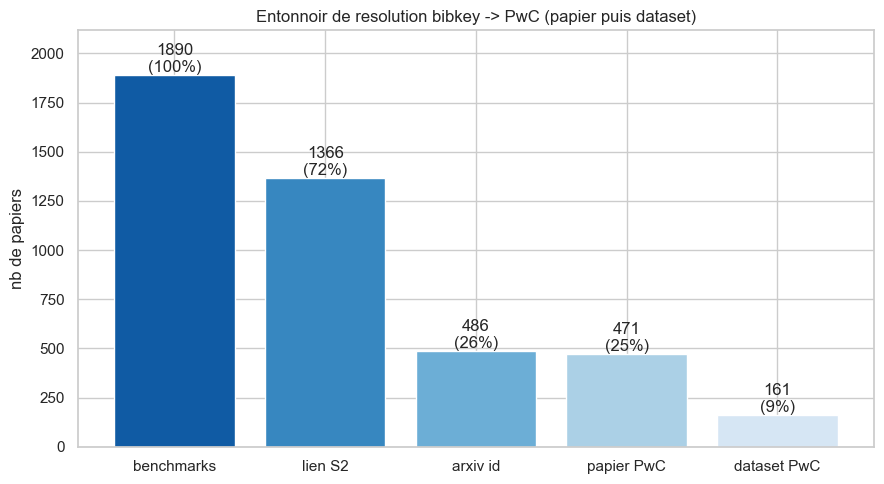

In [6]:
# --- Entonnoir de resolution (waterfall) ---
n_total = len(df)
n_s2 = int(df["s2_found"].sum())
n_arxiv = int(df["arxiv_norm"].notna().sum())
n_paper = int(df["in_pwc_paper"].sum())
n_dataset = int(df["in_pwc_dataset"].sum())

stages = ["benchmarks", "lien S2", "arxiv id", "papier PwC", "dataset PwC"]
values = [n_total, n_s2, n_arxiv, n_paper, n_dataset]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(stages, values, color=sns.color_palette("Blues_r", len(stages)))
for b, v in zip(bars, values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v,
        f"{v}\n({v / n_total * 100:.0f}%)",
        ha="center",
        va="bottom",
    )
ax.set_ylabel("nb de papiers")
ax.set_title("Entonnoir de resolution bibkey -> PwC (papier puis dataset)")
ax.set_ylim(0, n_total * 1.12)
plt.tight_layout()
plt.savefig(OUT_DIR / "funnel.png", dpi=150)
plt.show()

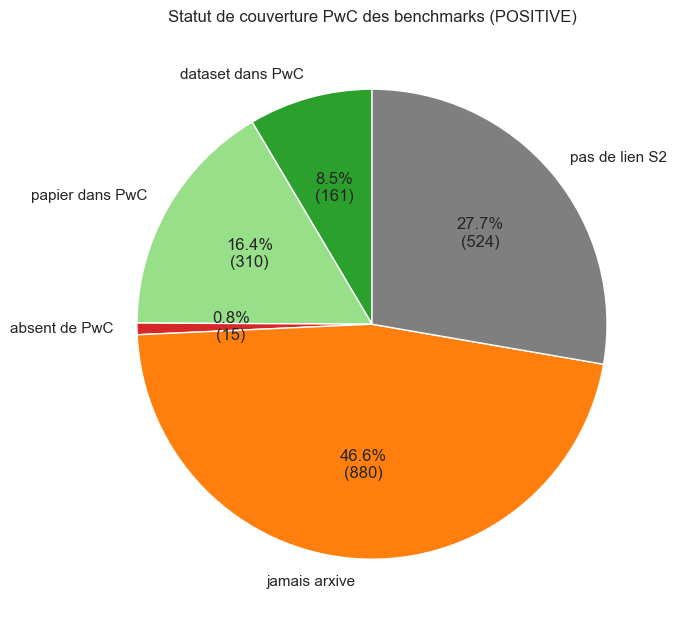

In [7]:
# --- Repartition des causes d'absence ---
order = [
    "dataset dans PwC",
    "papier dans PwC",
    "absent de PwC",
    "jamais arxive",
    "pas de lien S2",
]
order = [s for s in order if s in counts.index]
colors = {
    "dataset dans PwC": "#2ca02c",
    "papier dans PwC": "#98df8a",
    "absent de PwC": "#d62728",
    "jamais arxive": "#ff7f0e",
    "pas de lien S2": "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    counts[order],
    labels=order,
    autopct=lambda p: f"{p:.1f}%\n({p * len(df) / 100:.0f})",
    colors=[colors[s] for s in order],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
ax.set_title("Statut de couverture PwC des benchmarks (POSITIVE)")
plt.tight_layout()
plt.savefig(OUT_DIR / "coverage_pie.png", dpi=150)
plt.show()

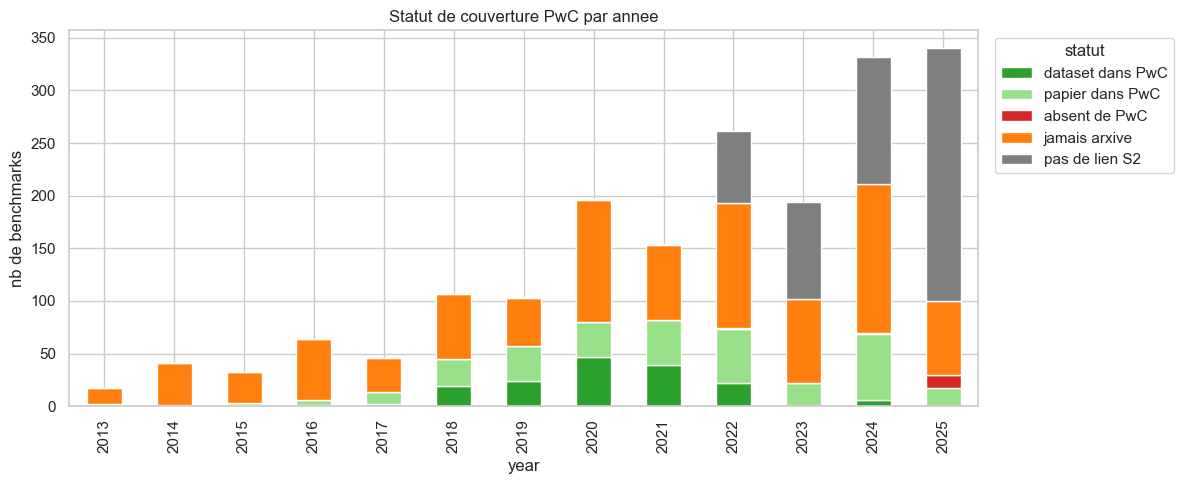

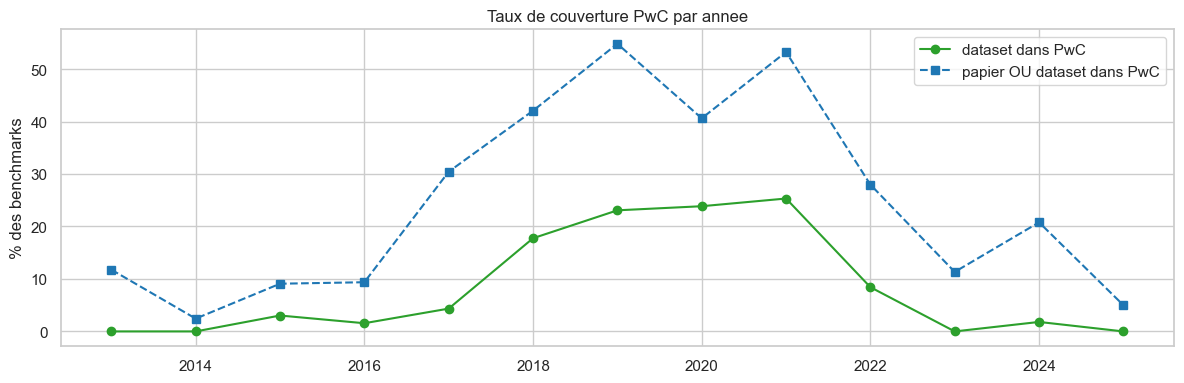

In [8]:
# --- Couverture par annee (stacked) ---
by_year = (
    df.dropna(subset=["year"])
    .assign(year=lambda d: d["year"].astype(int))
    .pivot_table(
        index="year",
        columns="coverage_status",
        values="bibkey",
        aggfunc="count",
        fill_value=0,
    )
)
by_year = by_year[[c for c in order if c in by_year.columns]]

ax = by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=[colors[c] for c in by_year.columns],
)
ax.set_ylabel("nb de benchmarks")
ax.set_title("Statut de couverture PwC par annee")
ax.legend(title="statut", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "coverage_by_year.png", dpi=150)
plt.show()

# taux de couverture par annee : dataset (strict) et papier (large)
rate = by_year.div(by_year.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12, 4))
if "dataset dans PwC" in rate.columns:
    ax.plot(rate.index, rate["dataset dans PwC"], marker="o",
            color=colors["dataset dans PwC"], label="dataset dans PwC")
both = [c for c in ["dataset dans PwC", "papier dans PwC"] if c in rate.columns]
if both:
    ax.plot(rate.index, rate[both].sum(axis=1), marker="s", linestyle="--",
            color="#1f77b4", label="papier OU dataset dans PwC")
ax.set_ylabel("% des benchmarks")
ax.set_title("Taux de couverture PwC par annee")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "coverage_rate_by_year.png", dpi=150)
plt.show()

## 6. Validation du recall (echantillon titre)

L'absence d'arxiv id est un signal propre, pas un bug. Mais il faut valider qu'on ne confond pas *"PwC ne l'a jamais indexe"* avec *"mon match a echoue"*. On prend ~50 benchmarks **avec** arxiv id classes `absent de PwC` et on verifie par **titre** (normalise) s'ils sont en realite dans PwC. Un recall titre eleve confirme que le match arxiv ne rate pas de vrais presents.

In [9]:
def norm_title(x) -> str:
    if not isinstance(x, str):
        return ""
    return "".join(ch for ch in x.lower() if ch.isalnum())


pwc_titles = set(pwc["title"].map(norm_title)) - {""}

sample = (
    df[(df["coverage_status"] == "absent de PwC")]
    .dropna(subset=["title"])
    .sample(min(50, (df["coverage_status"] == "absent de PwC").sum()), random_state=42)
    .copy()
)
sample["title_in_pwc"] = sample["title"].map(norm_title).isin(pwc_titles)

n_recovered = int(sample["title_in_pwc"].sum())
logger.info(
    "echantillon=%d | retrouves par titre=%d (%.1f%%)",
    len(sample),
    n_recovered,
    n_recovered / max(len(sample), 1) * 100,
)
print(
    f"Sur {len(sample)} 'absent de PwC' avec arxiv id, {n_recovered} retrouves par titre."
)
print(
    "-> match arxiv quasi-complet"
    if n_recovered <= 2
    else "-> ATTENTION: le match arxiv rate des presents, investiguer."
)
sample[sample["title_in_pwc"]][["bibkey", "title", "arxiv_id"]]

2026-05-25 14:21:50  INFO      echantillon=15 | retrouves par titre=0 (0.0%)


Sur 15 'absent de PwC' avec arxiv id, 0 retrouves par titre.
-> match arxiv quasi-complet


,bibkey,title,arxiv_id


## 7. Synthese chiffree

In [10]:
print(f"Benchmarks POSITIVE           : {n_total}")
print(f"  resolus via DOI             : {(df['s2_id_source'] == 'DOI').sum()}")
print(f"  resolus via ACL id          : {(df['s2_id_source'] == 'ACL').sum()}")
print(f"Avec lien Semantic Scholar    : {n_s2} ({n_s2 / n_total * 100:.1f}%)")
print(f"Avec arxiv id                 : {n_arxiv} ({n_arxiv / n_total * 100:.1f}%)")
print(f"Papier present dans PwC       : {n_paper} ({n_paper / n_total * 100:.1f}%)")
print(f"Dataset present dans PwC      : {n_dataset} ({n_dataset / n_total * 100:.1f}%)")
print()
print("Causes d'absence :")
print(summary.to_string())

Benchmarks POSITIVE           : 1890
  resolus via DOI             : 1219
  resolus via ACL id          : 671
Avec lien Semantic Scholar    : 1366 (72.3%)
Avec arxiv id                 : 486 (25.7%)
Papier present dans PwC       : 471 (24.9%)
Dataset present dans PwC      : 161 (8.5%)

Causes d'absence :
                    n     %
coverage_status            
jamais arxive     880  46.6
pas de lien S2    524  27.7
papier dans PwC   310  16.4
dataset dans PwC  161   8.5
absent de PwC      15   0.8
